In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt # Visualization

import sklearn
import statistics

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

import matplotlib.pyplot as plt

from sklearn.svm import SVR 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_val_score

file_path = 'Cinemark_data_for_all_algorithms.csv'

df = pd.read_csv(file_path)

df.set_index('Date_Time', inplace=True)
df = df.drop('Unnamed: 0', axis = 1)
display(df)

,Facility_Demand_Rate_kW,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD01_Zone_Mean_Air_Temperature,AUD01_HTG_SETPT,AUD01_CLG_SETPT,AUD02_Zone_Mean_Air_Temperature,AUD02_HTG_SETPT,AUD02_CLG_SETPT,AUD03_Zone_Mean_Air_Temperature,AUD03_HTG_SETPT,...,PROJC_CLG_SETPT,PROJD_Zone_Mean_Air_Temperature,PROJD_HTG_SETPT,PROJD_CLG_SETPT,OFFICE_Zone_Mean_Air_Temperature,OFFICE_HTG_SETPT,OFFICE_CLG_SETPT,EMPLOYEE_Zone_Mean_Air_Temperature,EMPLOYEE_HTG_SETPT,EMPLOYEE_CLG_SETPT
Date_Time,,,,,,,,,,,,,,,,,,,,,
01/01 00:05:00,190.426026,6.7,20.475174,20.0,23.8889,20.480841,20.0,23.8889,20.243276,20.0,...,23.8889,20.001310,20.0,23.8889,20.338029,20.0,23.8889,20.001048,20.0,23.8889
01/01 00:10:00,190.360637,6.7,20.033642,20.0,23.8889,20.047459,20.0,23.8889,20.424724,20.0,...,23.8889,19.999363,20.0,23.8889,20.306129,20.0,23.8889,20.000008,20.0,23.8889
01/01 00:15:00,190.331229,6.7,20.489567,20.0,23.8889,20.478936,20.0,23.8889,20.003879,20.0,...,23.8889,20.489683,20.0,23.8889,20.275221,20.0,23.8889,20.479038,20.0,23.8889
01/01 00:20:00,190.456673,6.7,20.056314,20.0,23.8889,20.043813,20.0,23.8889,20.520028,20.0,...,23.8889,20.093437,20.0,23.8889,20.244951,20.0,23.8889,20.057682,20.0,23.8889
01/01 00:25:00,190.297697,6.7,20.473177,20.0,23.8889,20.477356,20.0,23.8889,20.153758,20.0,...,23.8889,20.001184,20.0,23.8889,20.215148,20.0,23.8889,20.488301,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/31 23:40:00,190.877238,3.3,20.252889,20.0,23.8889,20.489481,20.0,23.8889,20.243799,20.0,...,23.8889,20.272905,20.0,23.8889,20.243910,20.0,23.8889,20.404130,20.0,23.8889
12/31 23:45:00,191.321030,3.3,20.244394,20.0,23.8889,20.006850,20.0,23.8889,20.244366,20.0,...,23.8889,20.244057,20.0,23.8889,20.508249,20.0,23.8889,20.006278,20.0,23.8889
12/31 23:50:00,190.905346,3.3,20.252896,20.0,23.8889,20.489467,20.0,23.8889,20.238186,20.0,...,23.8889,20.271679,20.0,23.8889,20.064467,20.0,23.8889,20.401844,20.0,23.8889


In [2]:
data = pd.DataFrame(df['Facility_Demand_Rate_kW'])

display(data)

# data.index = pd.to_datetime(data.index)


,Facility_Demand_Rate_kW
Date_Time,
01/01 00:05:00,190.426026
01/01 00:10:00,190.360637
01/01 00:15:00,190.331229
01/01 00:20:00,190.456673
01/01 00:25:00,190.297697
...,...
12/31 23:40:00,190.877238
12/31 23:45:00,191.321030
12/31 23:50:00,190.905346


In [3]:
# Total number of indices
total_indices = 105120

indices_per_month = 105120 / 12

# Calculate the starting and ending indices for July
july_start_index = int((7 - 1) * indices_per_month) - 432  # July start
july_end_index = (int(7 * indices_per_month) - 265) - 4464# July ends at the start of August (substract 4464 to get half of july)

# Print the range of indices corresponding to July
print("Range of indices corresponding to July:")
print("Start Index:", july_start_index)
print("End Index:", july_end_index - 1)  # Subtract 1 to get the index of the last interval in July

df_july = data.iloc[july_start_index:july_end_index + 1]

display(df_july)

Range of indices corresponding to July:
Start Index: 52128
End Index: 56590


,Facility_Demand_Rate_kW
Date_Time,
07/01 00:05:00,341.837389
07/01 00:10:00,300.925644
07/01 00:15:00,346.437052
07/01 00:20:00,295.422629
07/01 00:25:00,343.426935
...,...
07/16 11:40:00,403.051526
07/16 11:45:00,365.526081
07/16 11:50:00,414.470593


In [4]:
#Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller
adf, pvalue, usedlag_, nobs_, critical_values_, icbest_ = adfuller(df_july)
print("pvalue = ", pvalue, " if above 0.05, data is not stationary")

pvalue =  9.24991060376344e-09  if above 0.05, data is not stationary


In [25]:
from pmdarima.arima import auto_arima
#Autoarima gives us bet model suited for the data
# p - number of autoregressive terms (AR)
# q - Number of moving avergae terms (MA)
# d - number of non-seasonal differences
#p, d, q represent non-seasonal components
#P, D, Q represent seasonal components

arima_model = auto_arima(df_july['Facility_Demand_Rate_kW'], start_p = 0, d=0, start_q = 0, 
                          max_p = 1, max_q = 1, max_d=1, m = 96, 
                          start_P = 0, D=0, start_Q=0, max_P=1, max_D=1, max_Q=1,
                          seasonal = True, 
                          trace = True, 
                          error_action ='ignore',   
                          suppress_warnings = True,  
                          stepwise = True, n_fits=5)           
  
# To print the summary 
print(arima_model.summary() ) #Note down the Model and details.

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[96] intercept   : AIC=57616.308, Time=0.25 sec


KeyboardInterrupt: 

In [5]:
from statsmodels.tsa.arima.model import ARIMA as ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


#split the data into train and test
size = int(len(df_july) * 0.8)
X_train, X_test = df_july[0:size], df_july[size:len(df_july)]

# X_train32 = np.array(X_train, dtype=np.float32)
# X_test32 = np.array(X_test, dtype=np.float32)

# model = ARIMA(X_train['kW'],order = (1,0,0))
model = SARIMAX(X_train['Facility_Demand_Rate_kW'],order = (1,0,0), seasonal_order=(1,0,1,96))
result = model.fit()
print(result.summary())

c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will 

                                      SARIMAX Results                                       
Dep. Variable:              Facility_Demand_Rate_kW   No. Observations:                 3571
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 96)   Log Likelihood              -18305.404
Date:                              Mon, 06 May 2024   AIC                          36618.808
Time:                                      13:44:53   BIC                          36643.531
Sample:                                           0   HQIC                         36627.622
                                             - 3571                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9792      0.003    292.271      0.000       0.973       0.986
ar.S.L96       0.99

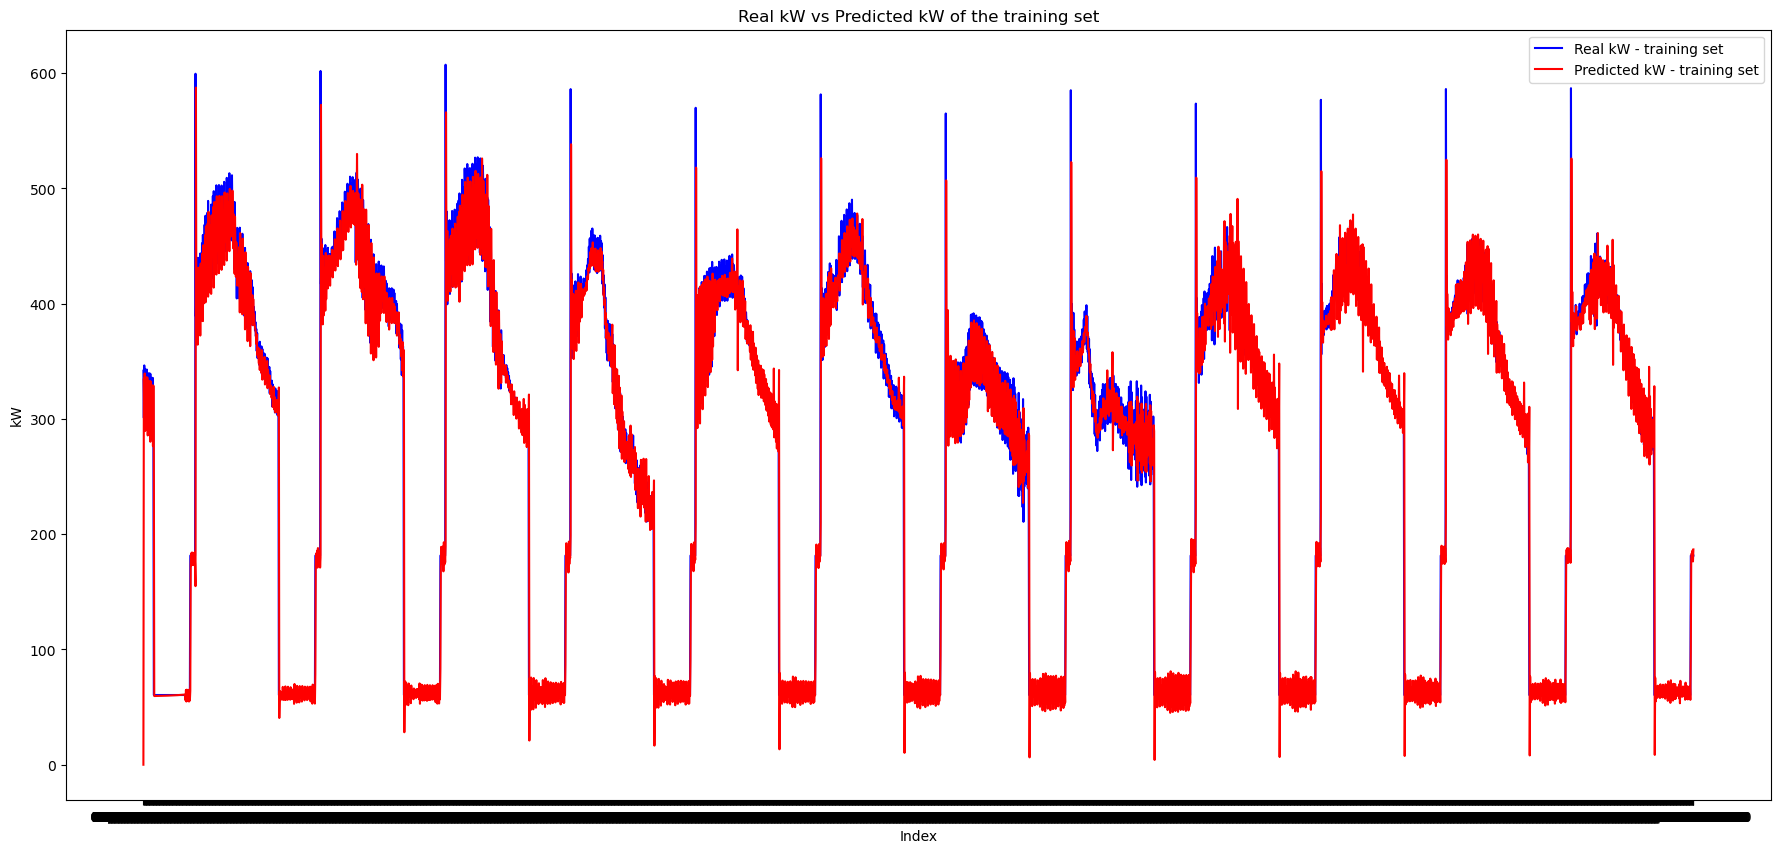

In [6]:
#Train prediction
start_index = 0
end_index = len(X_train)-1
train_prediction = result.predict(start_index,end_index) 

train_prediction = pd.DataFrame(train_prediction)

# train_prediction.set_index('Date Time', inplace=True)
# train_prediction.index = pd.to_datetime(train_prediction.index)

plt.figure(figsize=(22,10))

plt.plot(X_train["Facility_Demand_Rate_kW"], label="Real kW - training set", color="blue")
plt.plot(train_prediction["predicted_mean"], label="Predicted kW - training set", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW of the training set")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


<Axes: xlabel='Real kw - test set'>

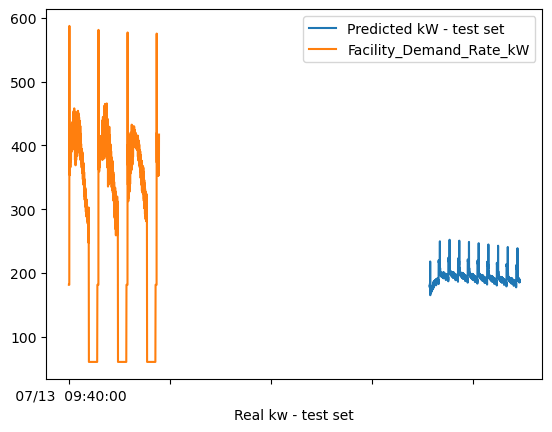

In [7]:
#Prediction
start_index2 = len(X_train)
end_index2 = len(df_july)-1
prediction = result.predict(start_index2, end_index2).rename('Predicted kW - test set') 

# plot predictions and actual values 
prediction.plot(legend = True) 
X_test['Facility_Demand_Rate_kW'].plot(legend = True, xlabel='Real kw - test set') 

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2_train = r2_score(X_train, train_prediction)
trainMaeScore = mean_absolute_error(X_train, train_prediction)
trainMseScore = mean_squared_error(X_train,  train_prediction)
print("R-squared value of the training set:", r2_train)
print("MAE of the training set:", trainMaeScore)
print("MSE of the training set:", trainMseScore)

r2_test = r2_score(X_test, prediction)
testMaeScore = mean_absolute_error(X_test, prediction)
testMseScore = mean_squared_error(X_test,  prediction)
print("R-squared value of the test set:", r2_test)
print("MAE of the test set:", testMaeScore)
print("MSE of the test set:", testMseScore)

R-squared value of the training set: 0.9293124031547959
MAE of the training set: 23.282857004562732
MSE of the training set: 1692.263651946026
R-squared value of the test set: -0.3274804205108488
MAE of the test set: 161.7438485205082
MSE of the test set: 29323.43520724611


c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


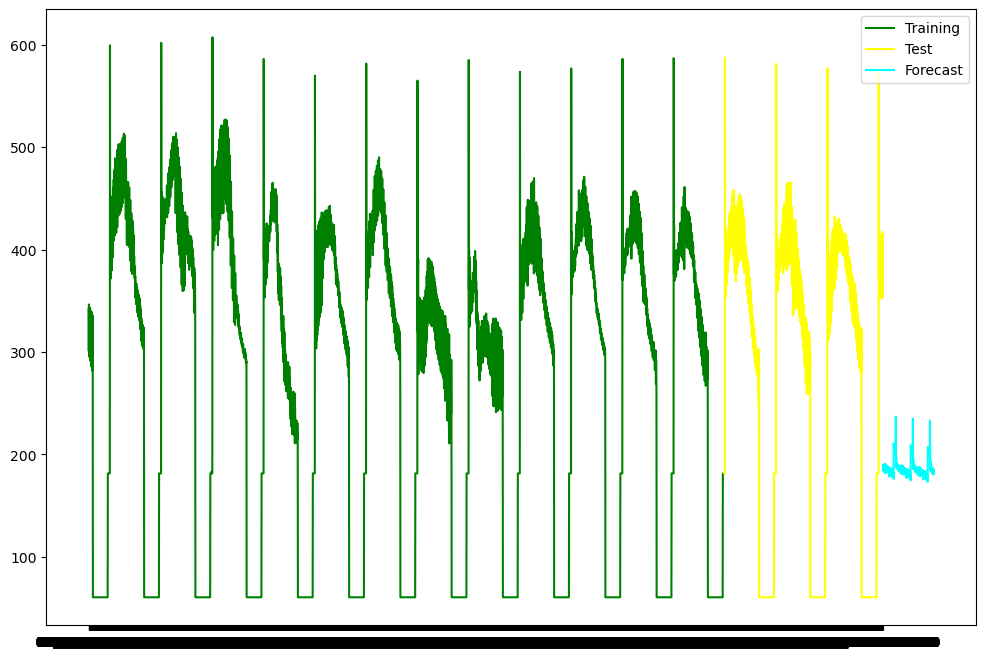

In [9]:
#Forecast.. You can re-train on the entire dataset before forecasting
#For now let us use the trained model
# Forecast for the next 3 years 
forecast = result.predict(start = len(df_july),  
                          end = (len(df_july)-1) + 3 * 96,  
                          typ = 'levels').rename('Forecast') 
  
plt.figure(figsize=(12,8))
plt.plot(X_train, label='Training', color='green')
plt.plot(X_test, label='Test', color='yellow')
plt.plot(forecast, label='Forecast', color='cyan')
plt.legend()
plt.show()